In [1]:
import numpy as np
# import torch
import matplotlib.pyplot as plt

In [2]:
predictions = np.load("validation_predictions_masked.npy")
targets = np.load("validation_targets_masked.npy")

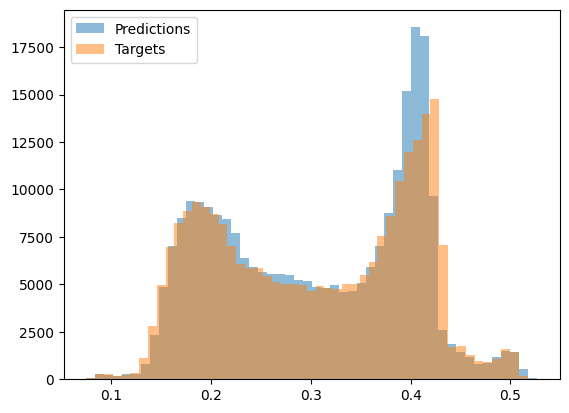

In [3]:
#plot histogram by removing the zeros
plt.hist(predictions[predictions != 0], bins=50, alpha=0.5, label='Predictions')
plt.hist(targets[targets != 0], bins=50, alpha=0.5, label='Targets')
plt.legend()

In [4]:
print(predictions.shape)
print(targets.shape)

(719, 3, 33, 25)
(719, 3, 33, 25)


In [5]:
from sklearn.metrics import mean_squared_error

In [6]:
max_mse = np.zeros(3)
min_mse = np.inf * np.ones(3)
max_idx = np.zeros(3, dtype=int)
min_idx = np.zeros(3, dtype=int)
for i in range(predictions.shape[0]):
    mse = mean_squared_error(targets[i][0], predictions[i][0])
    if mse > max_mse[0]:
        max_mse[0] = mse
        max_idx[0] = i
    if mse < min_mse[0]:
        min_mse[0] = mse
        min_idx[0] = i
    mse = mean_squared_error(targets[i][1], predictions[i][1])
    if mse > max_mse[1]:
        max_mse[1] = mse
        max_idx[1] = i
    if mse < min_mse[1]:
        min_mse[1] = mse
        min_idx[1] = i
    mse = mean_squared_error(targets[i][2], predictions[i][2])
    if mse > max_mse[2]:
        max_mse[2] = mse
        max_idx[2] = i
    if mse < min_mse[2]:
        min_mse[2] = mse
        min_idx[2] = i

    
    

In [7]:
print(max_mse)
print(min_mse)
print(max_idx)
print(min_idx)

[0.00189091 0.00390557 0.00404659]
[1.95320058e-06 2.63470565e-06 2.74079161e-06]
[118 118 117]
[380 691 716]


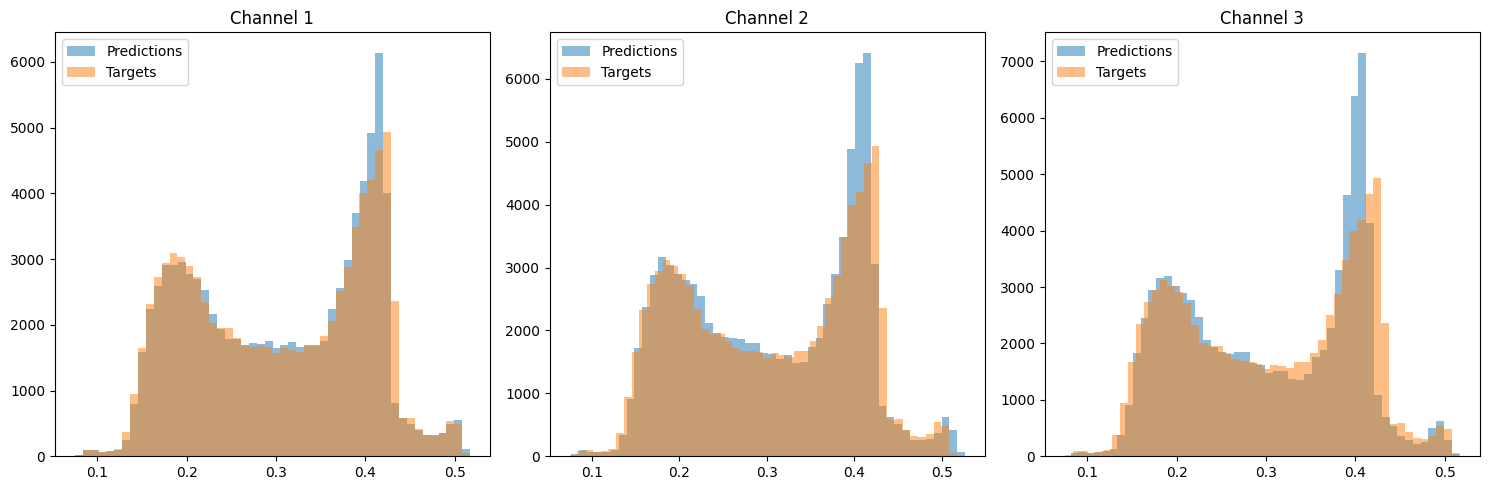

In [11]:
#plot histogram of actual and predicted values frequency for all three channels
plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.hist(predictions[:, i][predictions[:, i] != 0], bins=50, alpha=0.5, label='Predictions')
    plt.hist(targets[:, i][targets[:, i] != 0], bins=50, alpha=0.5, label='Targets')
    plt.legend()
    plt.title(f'Channel {i+1}')
plt.tight_layout()
plt.show()

In [8]:
# #plot the actual, predicted and scatter plot for the max and min mse for each of the 3 parameters


# for i in range(3):
#     plt.figure(figsize=(15, 5))
#     plt.subplot(1, 3, 1)
#     plt.imshow(targets[max_idx[i]][i], cmap='viridis', label='Actual')
#     plt.title(f'Actual Soil Moisture (T + {i+1})')
#     plt.colorbar()
#     # plt.legend()
    
#     plt.subplot(1, 3, 2)
#     plt.imshow(predictions[min_idx[i]][i], cmap='viridis', label='Predicted')
#     plt.title(f'Predicted Soil Moisture (T + {i+1})')
#     plt.colorbar()
#     # plt.legend()
    
#     plt.subplot(1, 3, 3)
#     plt.scatter(targets[max_idx[i]][i], predictions[max_idx[i]][i])
#     plt.grid()
#     #plot y = x for max value of x and y
#     max_val = max(np.max(targets[max_idx[i]][i]), np.max(predictions[max_idx[i]][i]))
#     plt.plot([0, max_val], [0, max_val], 'b--', alpha=0.5)
#     plt.xlabel('Actual')
#     plt.ylabel('Predicted')
#     plt.title(f'Scatter plot for max MSE (T + {i+1})')

In [9]:
# #now plot for the min mse but one single image
# for i in range(3):
#     plt.figure(figsize=(15, 5))
#     plt.subplot(1, 3, 1)
#     plt.imshow(targets[min_idx[i]][i], cmap='viridis', label='Actual')
#     plt.title(f'Actual Soil Moisture (T + {i+1})')
#     plt.colorbar()
#     # plt.legend()
    
#     plt.subplot(1, 3, 2)
#     plt.imshow(predictions[min_idx[i]][i], cmap='viridis', label='Predicted')
#     plt.title(f'Predicted Soil Moisture (T + {i+1})')
#     plt.colorbar()
#     # plt.legend()
    
#     plt.subplot(1, 3, 3)
#     plt.scatter(targets[min_idx[i]][i], predictions[min_idx[i]][i])
#     plt.grid()
#     #plot y = x for max value of x and y
#     max_val = max(np.max(targets[min_idx[i]][i]), np.max(predictions[min_idx[i]][i]))
#     plt.plot([0, max_val], [0, max_val], 'b--', alpha=0.5)
#     plt.xlabel('Actual')
#     plt.ylabel('Predicted')
#     plt.title(f'Scatter plot for min MSE (T + {i+1})')